<a href="https://colab.research.google.com/github/baanujan-18/Quanser_mobile_robot-fYP/blob/main/Vibration/E20030_Baanu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                                      **Vibration**


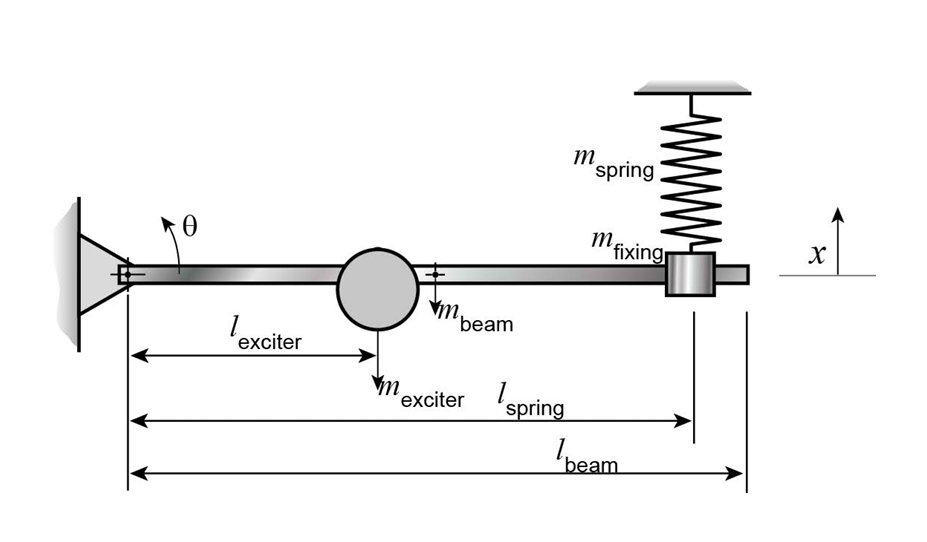

The experimental setup consists of a rigid beam that is pinned at one end, allowing rotation about the support. An unbalanced exciter motor is mounted on the beam at an intermediate location to provide harmonic excitation. The other end of the beam is connected to the frame through a vertical spring, which supports the beam elastically and permits vertical motion of the free end. The beam has distributed mass, while additional masses are associated with the exciter, the spring, and the fixing at the spring end. The geometry of the system is defined by the beam length, the position of the exciter, and the position of the spring attachment. This configuration allows the study of free and forced vibrations of the beam–spring system under controlled excitation conditions.

For a slender beam subjected to small-amplitude transverse vibrations, the structural response can be effectively modeled as a continuous system based on Euler--Bernoulli beam theory. The governing partial differential equation for the transverse displacement \( y(x,t) \) is given by

$$ {\rho A}{{\partial^2 y} \over {\partial t^2}} + c{{\partial y} \over {\partial t}}+EI{{\partial^4 y} \over {\partial x^4}}+P {{\partial^2 y} \over {\partial x^2}}=f(t,x) $$

where \( \rho \) denotes the material density of the beam, \( A \) is the uniform cross-sectional area, \( E \) is Young’s modulus, and \( I \) represents the second moment of area of the cross section. The parameter \( P \) corresponds to the applied axial compressive force, while \( c \) is the distributed viscous damping coefficient per unit length. The function \( f(t,x) \) represents the external transverse load acting per unit length along the beam.


Since $P = 0$ for this case, the above PDE can be reduced to:

$$
{\rho A}{{\partial^2 y} \over {\partial t^2}} + c{{\partial y} \over {\partial t}}+EI{{\partial^4 y} \over {\partial x^4}}=f(t,x)
$$


The solutions of the above PDE that satisfy the boundary conditions of a pinned-free beam.

\begin{align*}y(0,t)&=0,\:\:\:\:\:\:\: {\partial^3 y \over \partial x^3}(l_{beam},t)=0,\\{\partial^2 y \over \partial x^2}(0,t)&=0,\:\:\:\:\:\:\: {\partial^2 y \over \partial x^2}(l_{beam},t)=0,\end{align*}

**Free Vibration Analysis for Mode Shapes:**

Let $\mathfrak{F}$ be the infintie dimensional vector space of twice differentiable functions defined on the interval $[0,L]$. Then $H: \mathfrak{F}\mapsto \mathfrak{F}$ defined by

\begin{align}H&=\frac{EI} {\rho A}{{\partial^4 } \over {\partial x^4}}
\end{align}

is a linear operator on $\mathfrak{F}$ and the equations of motion take the form

\begin{align*}
{{\partial^2 y} \over {\partial t^2}} + C{{\partial y} \over {\partial t}}+Hy&=q(t,x)
\end{align*}

where $c = C \rho A$ and $f(t) = \rho A q(t)$

$H$ maps a transverse deflection shape to the acceleration caused purely by beam bending, subject to the beam’s boundary conditions. Let $H$ have distinct positive eignevalues $\{\omega_k^2\}_{k=1}^\infty$ with corrsponding eigenvectors $\{\psi_k\}_{k=1}^\infty$ i.e. mode shapes.

Then, the eigenvalue problem can be defined as:

\begin{align*}
H \psi_k(x) &= \omega_k^2 \psi(x)
\end{align*}

Substituting $(1)$, we get:

\begin{align*}
\frac{EI}{\rho A} \frac{\partial^4 \psi_k(x)}{\partial x^4} &= \omega_k^2 \psi_k(x) \\
\frac{\partial^4 \psi_k(x)}{\partial x^4} &= \frac{\rho A \, \omega_k^2}{EI} \psi_k(x)  \\
\frac{\partial^4 \psi_k(x)}{\partial x^4} &= \beta_k^4 \psi_k(x)
\end{align*}

where $\beta_k^4 = \frac{\rho A \, \omega_k^2}{EI}$

The general solution of the fourth-order differential equation $(1)$ is

\begin{align*}
\psi_k(x) = A_k \cosh(\beta_k x) + B_k \sinh(\beta_k x) + C_k \cos(\beta_k x) + D_k \sin(\beta_k x)
\end{align*}

where $A_k$, $B_k$, $C_k$, $D_k$ are constants determined from boundary conditions.

Boundary conditions at pinned-end:

\begin{align*}
\psi_k(0) &= 0 \quad \Rightarrow \quad A_k + C_k = 0 \\
\psi_k''(0) &= 0 \quad \Rightarrow \quad A_k - C_k = 0
\end{align*}

Solving this, we get:

$$
A_k = C_k = 0
$$

Hence

\begin{align*}
\psi_k(x) = B_k \sinh(\beta_k x) + D_k \sin(\beta_k x)
\end{align*}

Boundary conditions at free-end:

\begin{align*}
\psi_k''(l_{beam}) = 0 \Rightarrow B_k \sinh(\beta_k l_{beam}) - D_k \sin(\beta_k l_{beam}) = 0 \\
\psi_k'''(l_{beam}) = 0 \Rightarrow B_k \cosh(\beta_k l_{beam}) - D_k \cos(\beta_k l_{beam}) = 0
\end{align*}

For a non-trivial solution $(B_k, D_k) \neq (0,0)$, this simplifies to:

$$
\tan(\beta_k l_{beam}) = \tanh(\beta_k l_{beam})
$$

Let us solve the above transcendental equation numerically to find $\beta_k$ for $k \in \mathbb{N}$.


In [ ]:
import numpy as np
from scipy.optimize import brentq

# Use a continuous equivalent: h(s) = sin(s)*cosh(s) - sinh(s)*cos(s)
def h(s):
    return np.sin(s) * np.cosh(s) - np.sinh(s) * np.cos(s)

roots = []
n_roots = 2 # Number of roots to be found
s_min = 1e-6
s_max = 50.0 # Increase if required
s_vals = np.linspace(s_min, s_max, 20000)

for i in range(len(s_vals) - 1):
    a, b = s_vals[i], s_vals[i+1]
    fa, fb = h(a), h(b)
    # sign change -> root in (a,b)
    if fa == 0:
        roots.append(a)
    elif fa * fb < 0:
        try:
            root = brentq(h, a, b)
            # avoid duplicates caused by fine sampling
            if len(roots) == 0 or abs(root - roots[-1]) > 1e-6:
                roots.append(root)
        except ValueError:
            pass
    if len(roots) >= n_roots:
        break

for i, r in enumerate(roots, 1):
    print(f"root {i}: beta*l_beam = {r:.6f}")
print(f"root {i+1}: ....")

Then, the eigenvalues of $H$ are given by,

$$
\{\omega_k^2\}_{k=1}^\infty = \left\{\frac{EI}{\rho A}{\beta_k}^4\right\}_{k=1}^\infty
$$

and the eigenvectors/mode shapes of $H$ are given by,

$$
\{\psi_k\}_{k=1}^\infty = \left\{B_k \sinh(\beta_k x) + D_k \sin(\beta_k x)\right\}_{k=1}^\infty
$$

where $\frac{B_k}{D_k} = \frac{\sin{(\beta_k l_{beam})}}{\sinh{(\beta_k l_{beam})}} = \frac{\cos{(\beta_k l_{beam})}}{\cosh{(\beta_k l_{beam})}}$

# **Experiment 01** : **Introduction to the Equipment**

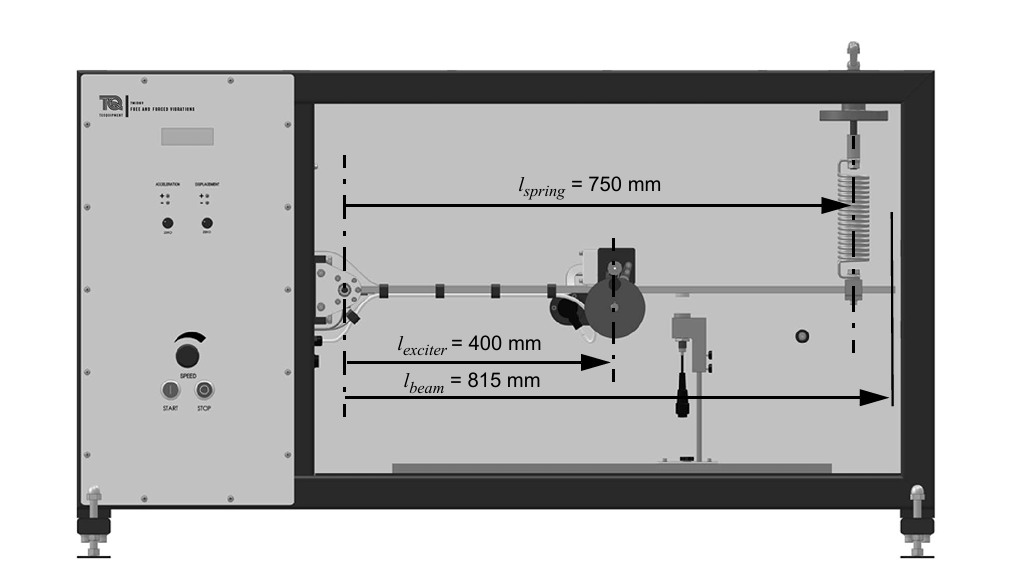

The system consists of a horizontal beam rigidly mounted within a fixed supporting frame.
An electromechanical exciter is attached to the beam at a distance of
$l_{\text{exciter}} = 400~\mathrm{mm}$ from the fixed end, providing controlled vibrational excitation.

The total length of the beam is $l_{\text{beam}} = 815~\mathrm{mm}$.
At the free end of the beam, a linear spring is connected vertically, with an effective spring length of
$l_{\text{spring}} = 750~\mathrm{mm}$, supplying the elastic restoring force to the system.

This beam–spring configuration is employed to investigate the dynamic response of the structure under external excitation.
The experimental data obtained from this setup in Experiment~1 are used for subsequent analysis and validation of the system’s dynamic behavior.


**Procedure 1 -Free Vibration Displacement**

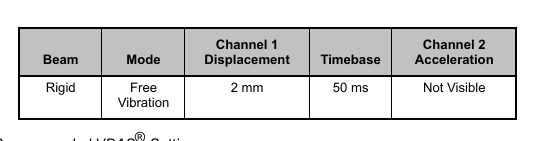

WE set like this in VDAS Software and take the dispalcement curve.

**Displacement Curve**

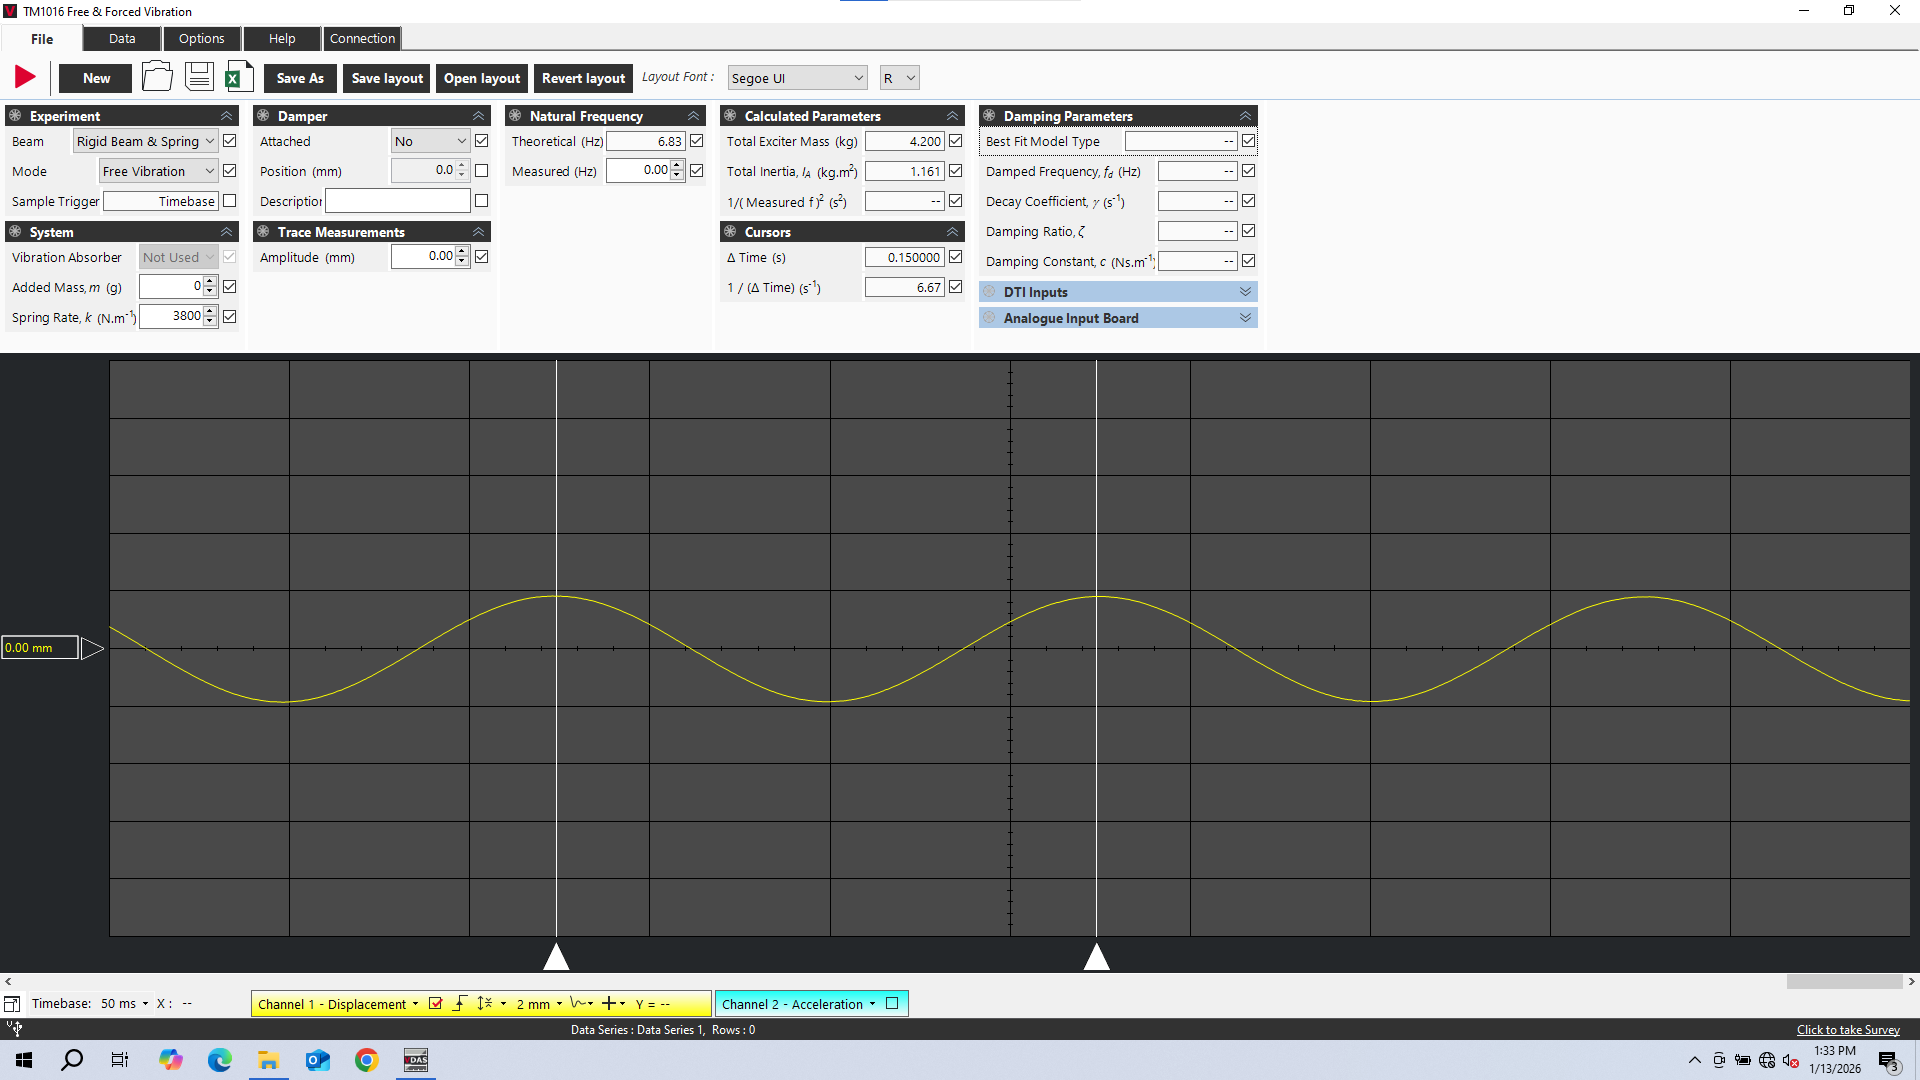

This plot shows the displacement of the beam during free vibration. The motion is sinusoidal, indicating simple harmonic motion. The beam oscillates at its natural frequency after being disturbed and released. The constant spacing between peaks confirms a nearly constant natural frequency.

In this one you see the **theoretical frequency is 6.83 Hz** but we got the **experimental frequency as 6.67 Hz** through VDAS.

**Procedure 2 - Displacement 1st Derivative (Velocity)**


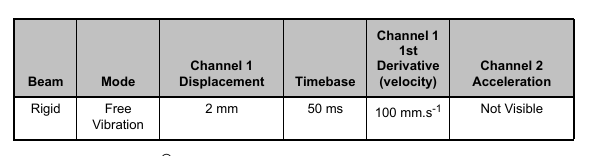

We set the VDAS settings like the above the table.

This figure showing that the velocity is 90 degrees out of phase from displacement. The
relative amplitudes are not important and will not be equal.


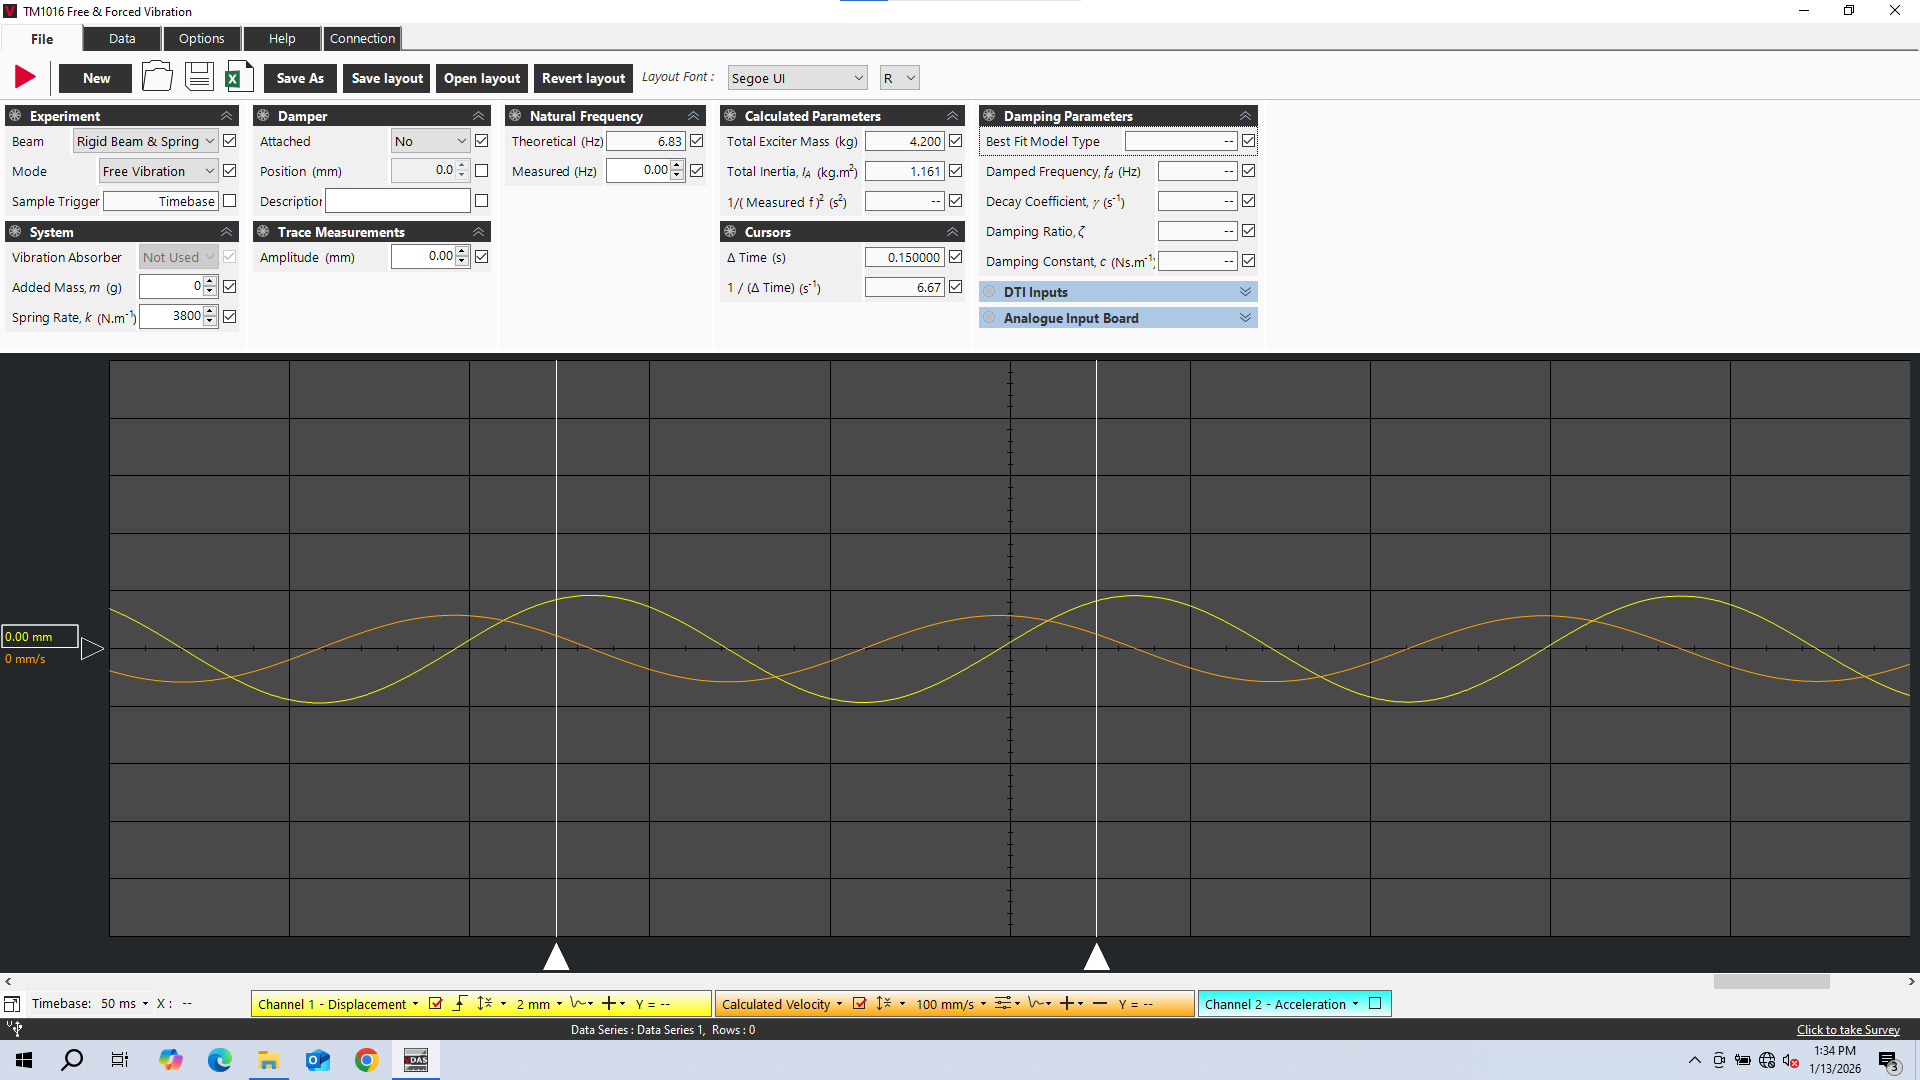

This figure shows both displacement and the calculated velocity of the beam. The velocity waveform is shifted by 90° relative to displacement. Maximum velocity occurs when the displacement crosses the equilibrium position, which agrees with vibration theory.

**Procedure 3 - Displacement 2nd Derivative (Acceleration)**

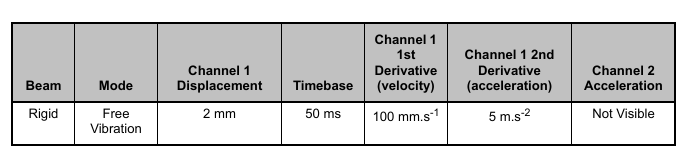

We set the VDAS settings like the above the table.

**Typical Displacement with First Derivative (velocity) and Second Derivative Curves :**




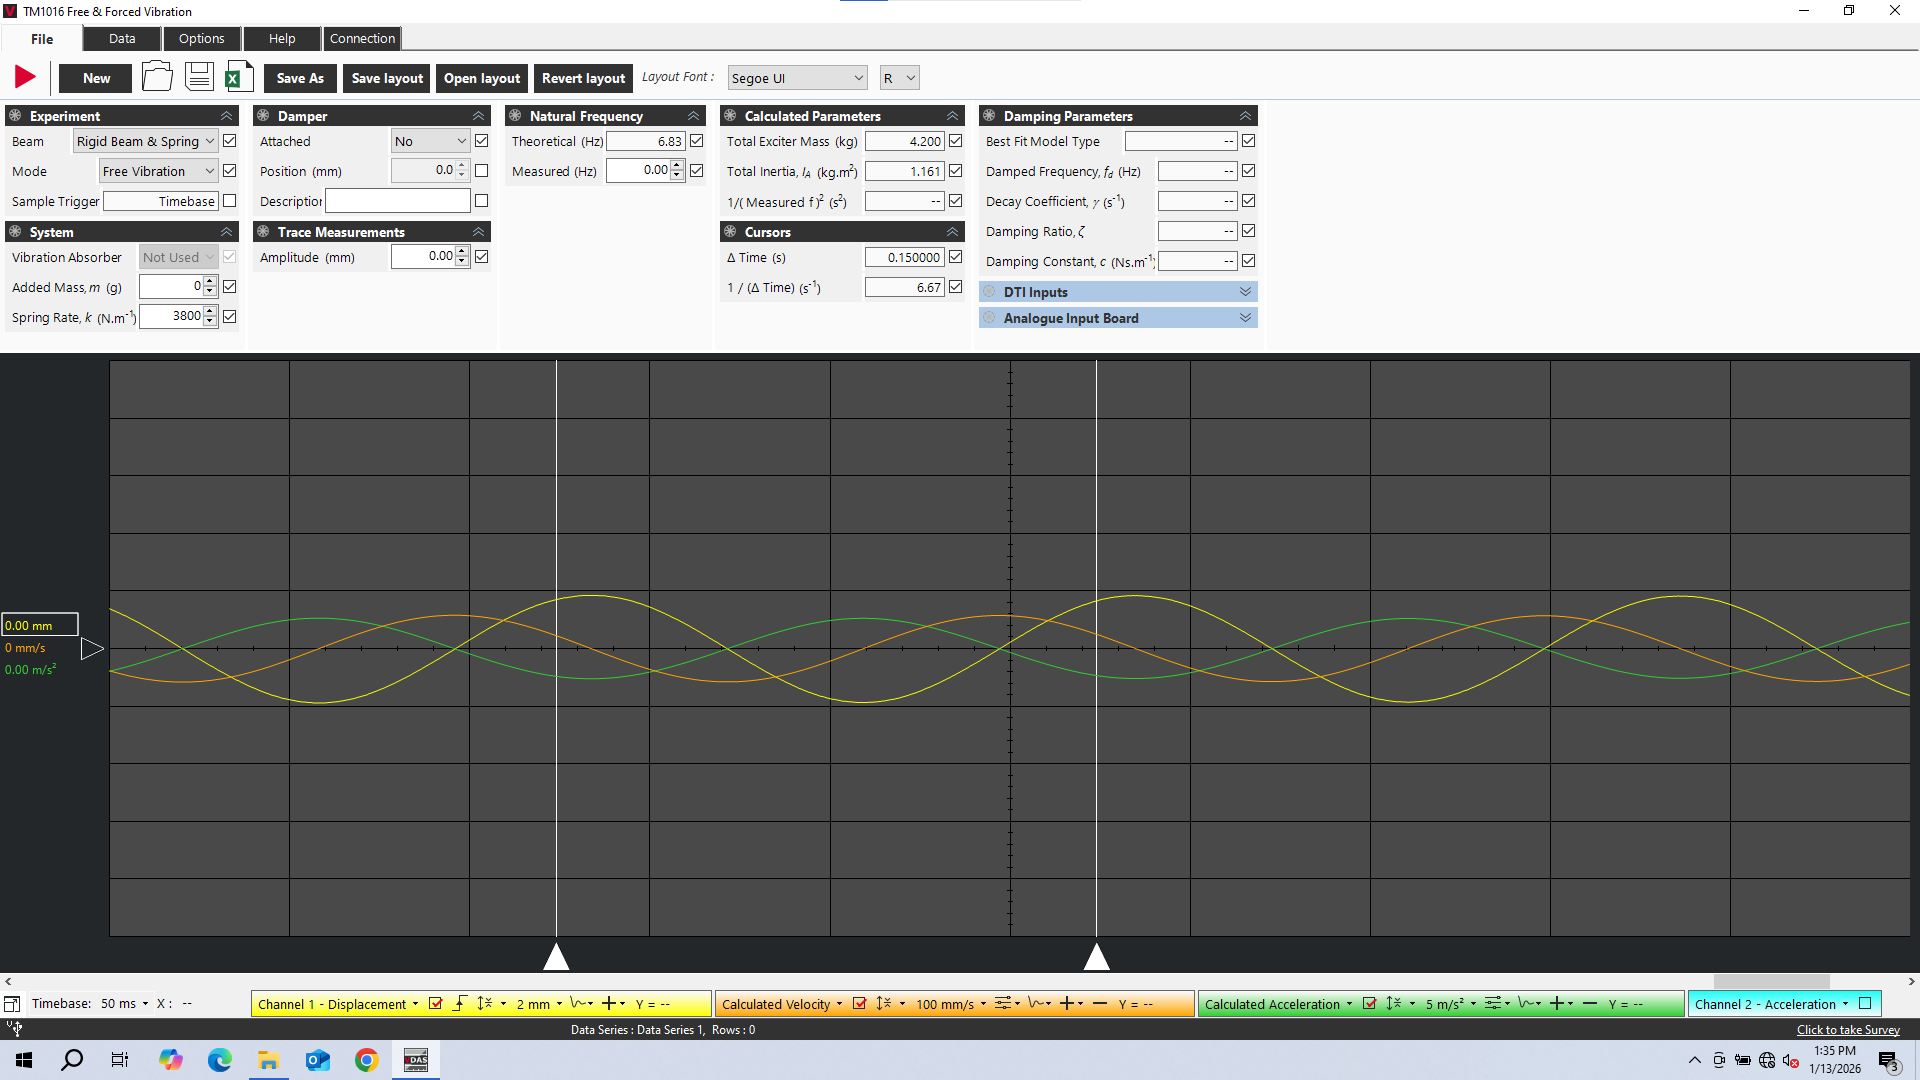

This plot includes displacement, calculated velocity, and calculated acceleration. The acceleration waveform is 180° out of phase with displacement. This phase relationship confirms the theoretical relationship between displacement, velocity, and acceleration in free vibration.

**Procedure 4 - Measured Acceleration**

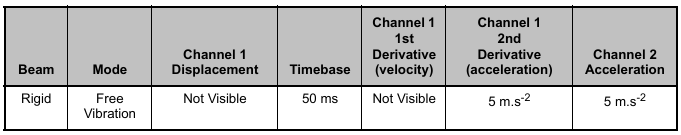

We set the VDAS settings as the above table.

**Typical Second Derivative and Channel 2 Curves** :

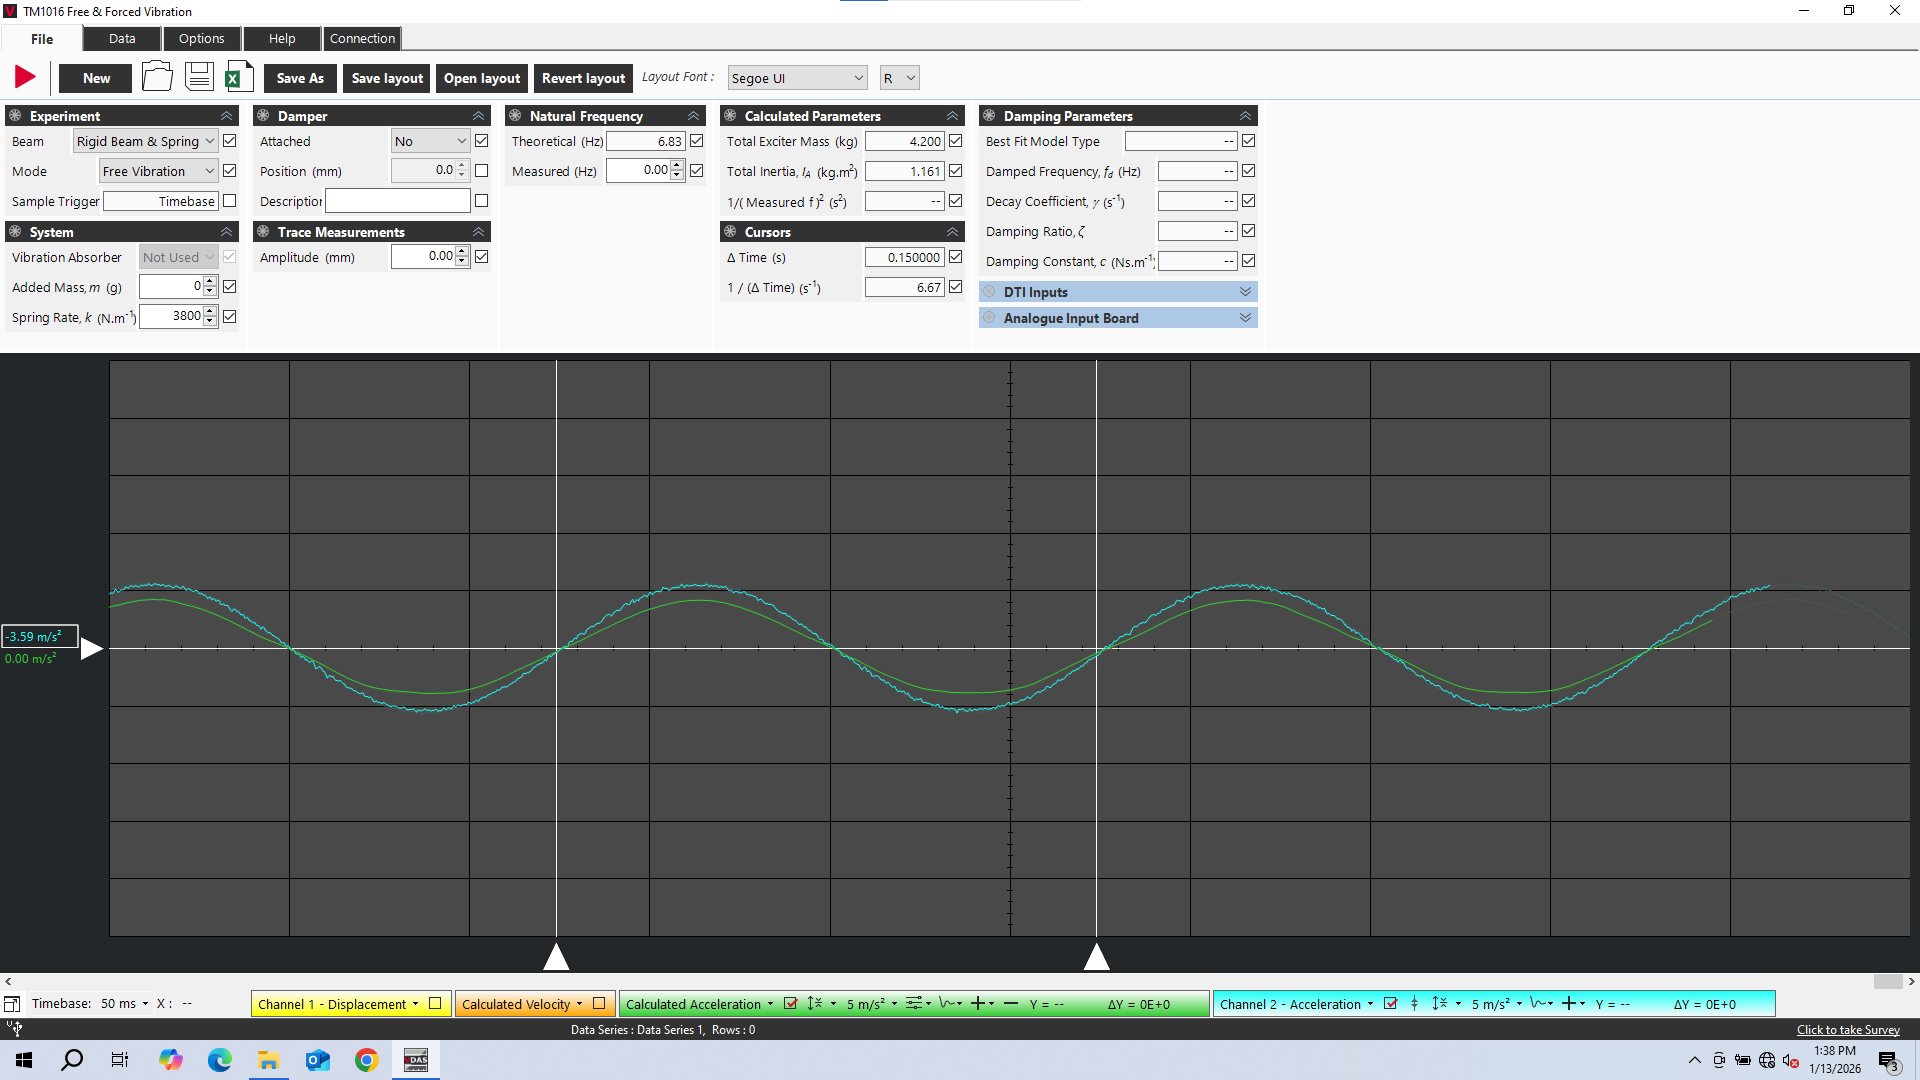

This figure compares the calculated acceleration with the acceleration measured using the accelerometer. Both waveforms closely match in shape and phase, showing good agreement between measured and calculated acceleration and validating the sensor data.

**Procedure 5 - Forced Vibration Displacement**

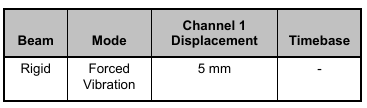

We set the VDAS settings as the above table.

**Typical Forced Vibration Curve** :

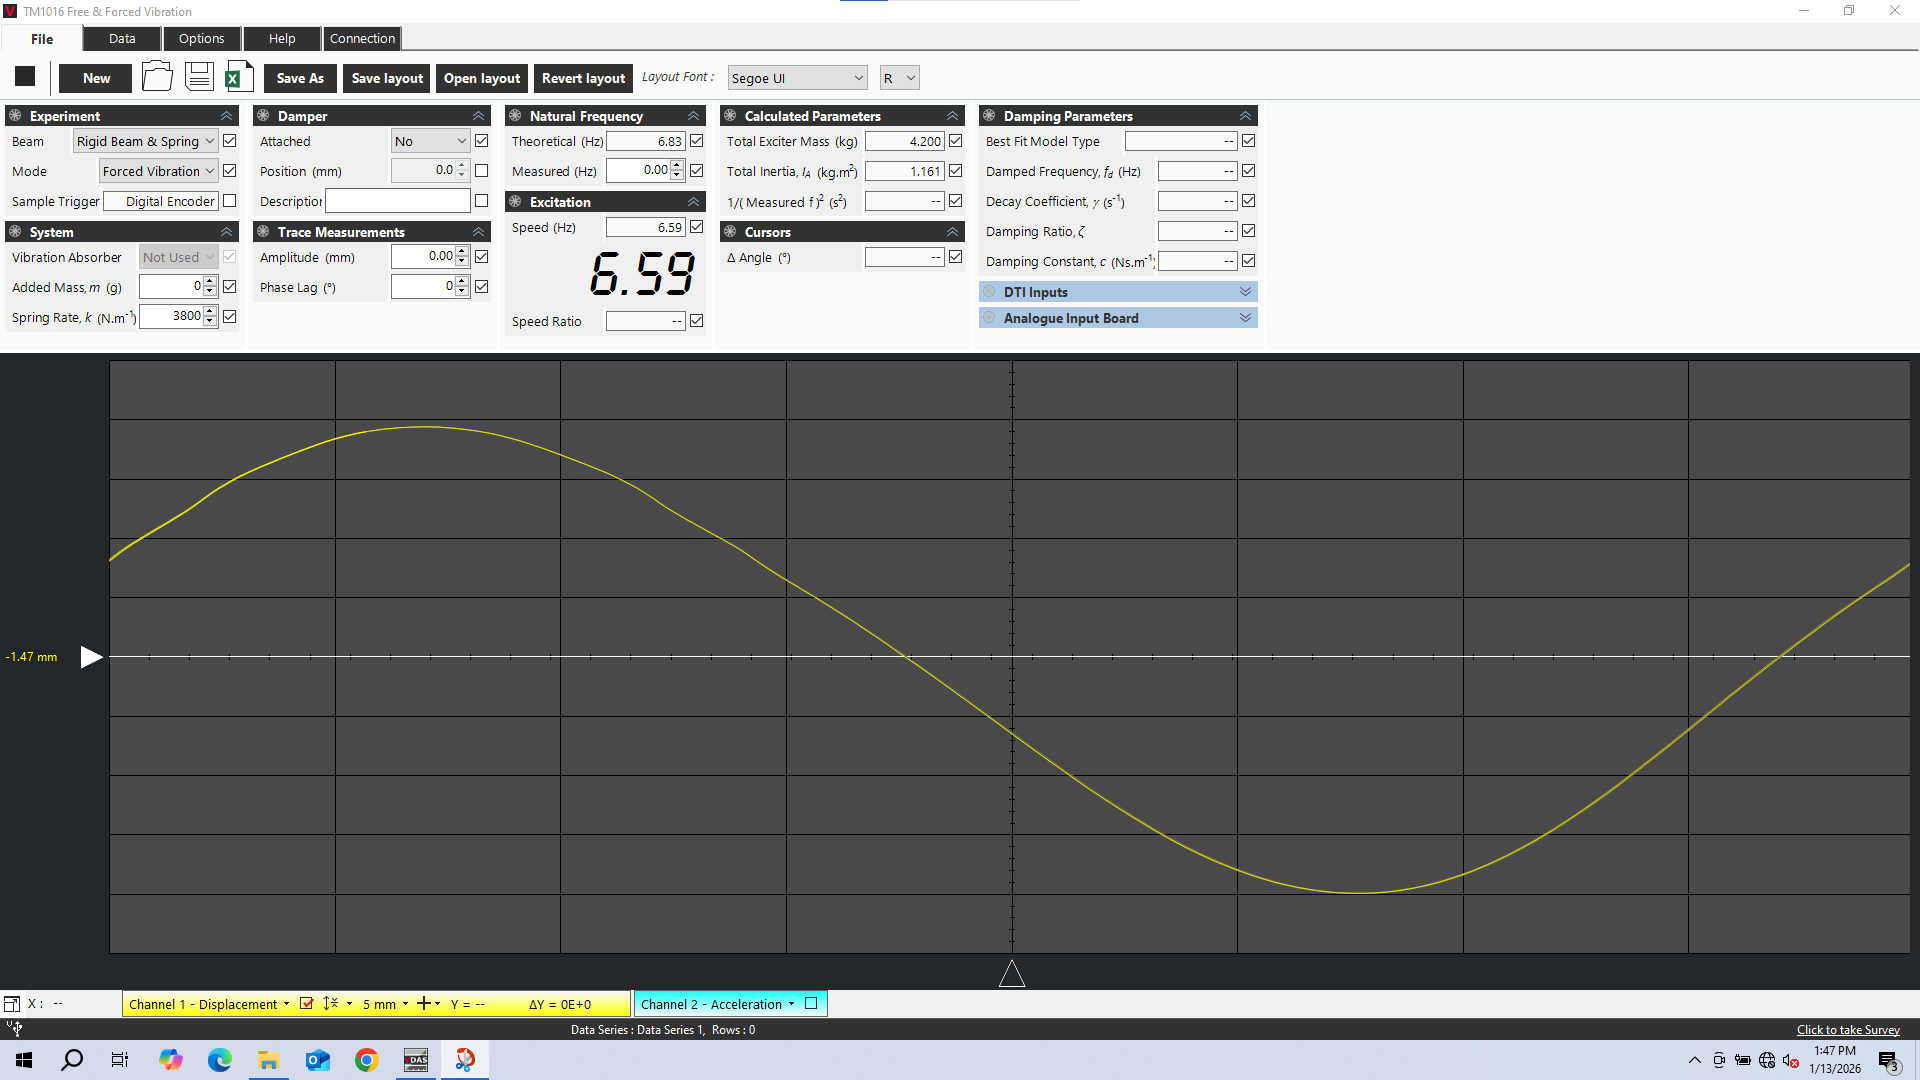

This plot shows the beam displacement under forced vibration at an excitation frequency of approximately 6.59 Hz. The displacement amplitude remains steady, indicating a stable forced response. The excitation frequency is close to the natural frequency, resulting in a noticeable vibration amplitude.

**Procedure 6 - Damping Ratio**

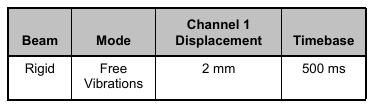

We set the VDAS as the above table.

**Typical Free Vibration Curve Showing Damping Model** ⁉

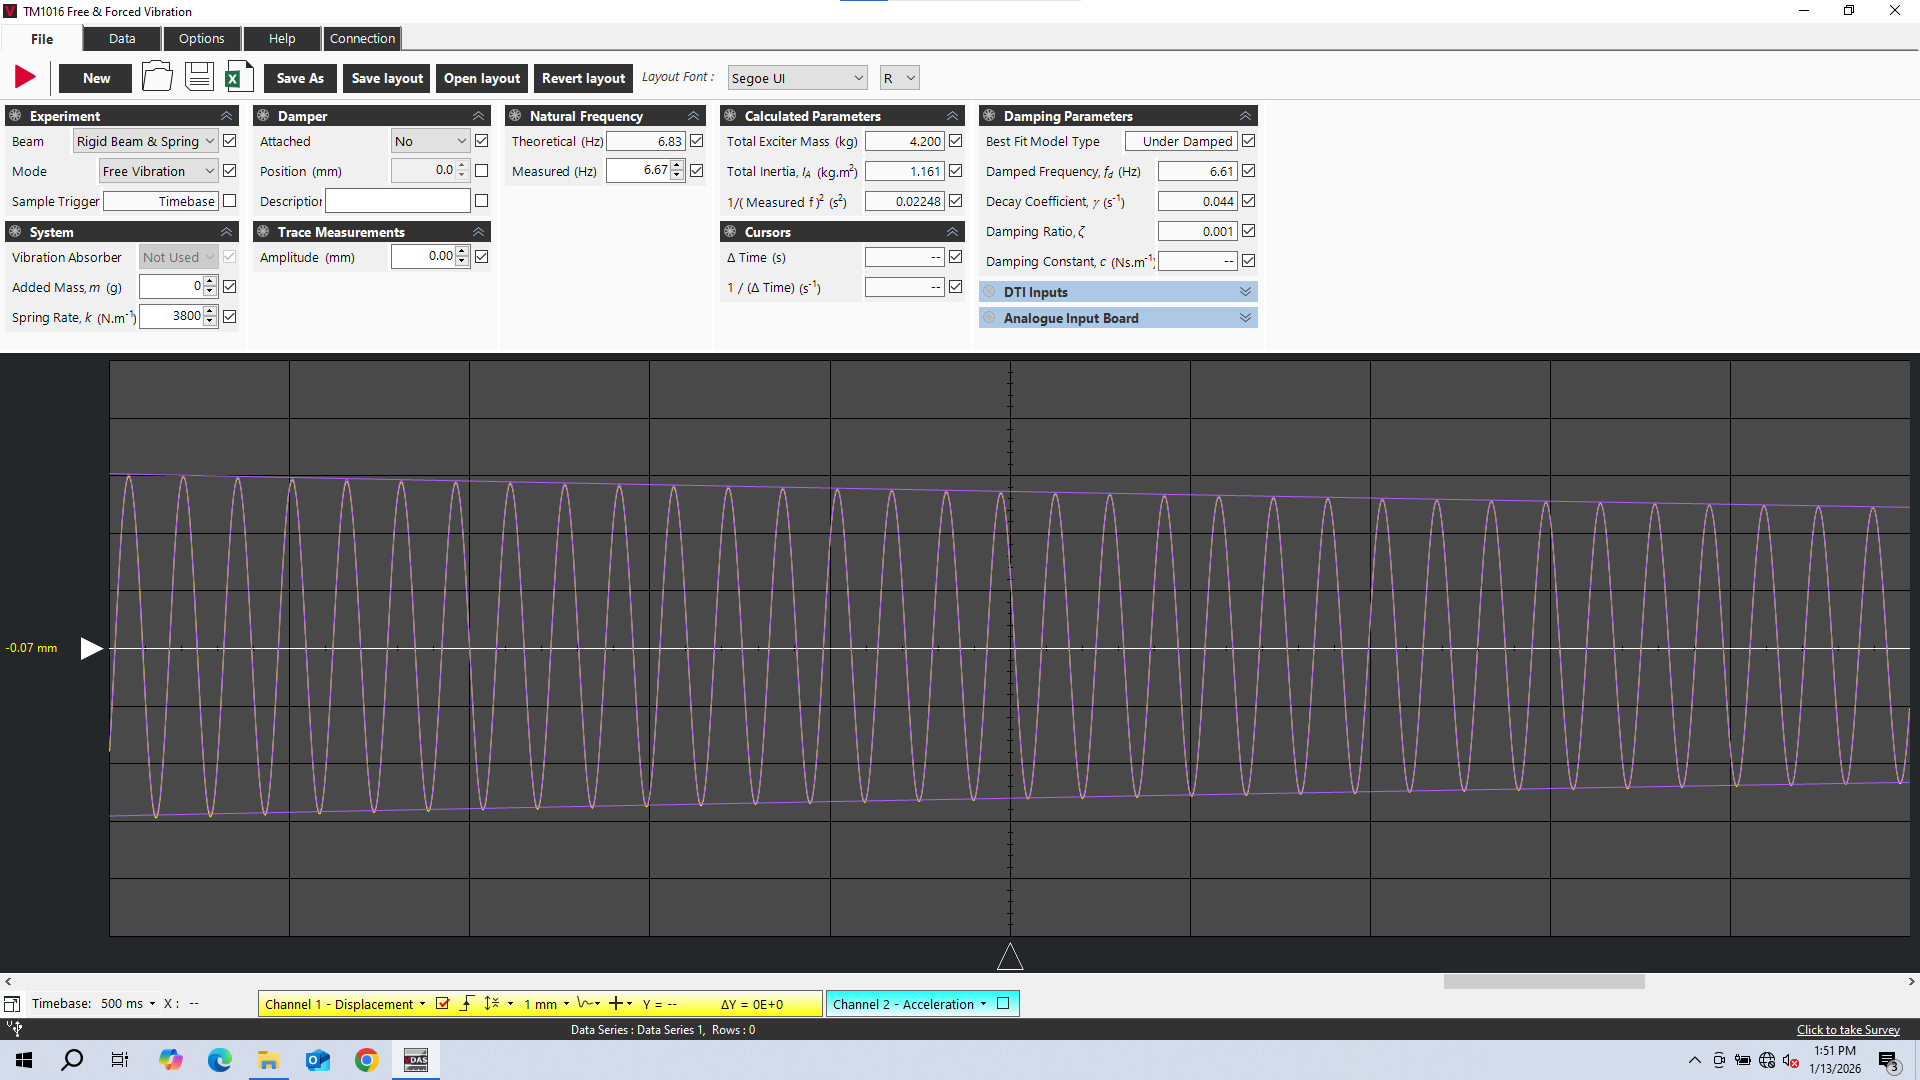

This figure shows a decaying vibration envelope used to calculate damping parameters. The gradual reduction in amplitude indicates an underdamped system. From the decay curve, the damping ratio is found to be very small, confirming that the system experiences light damping.

# **Experiment 02** : **Rigid Beam and Spring - Added Mass**

Some procedures and measurements mentioned in the experiment manual could not be performed due to equipment or setup unavailability. Therefore, only the available and operational procedures were conducted, and the corresponding results are presented.

# **Experiment 03** : **Rigid Beam and Spring - Damping**

**Lab Setup :**

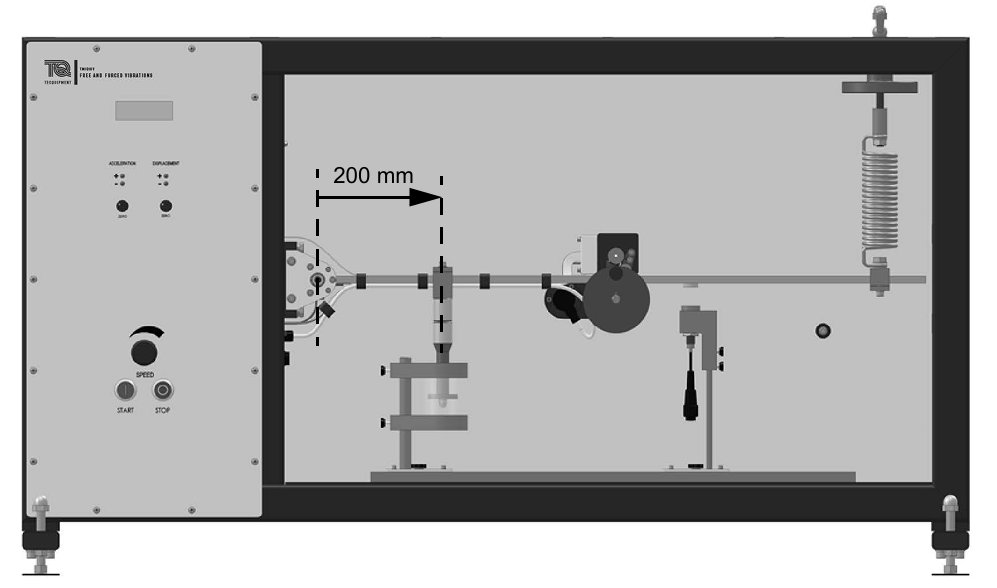

The above figure shows the laboratory setup used for Experiment 3, which investigates the effect of damping on a rigid beam–spring system. The beam is rigidly supported at the left end by a low-friction pivot, allowing it to oscillate about this point. An electromechanical exciter is mounted on the beam to initiate vibration when required.

A dashpot damper is attached vertically to the beam at a distance of 200 mm from the pivot, as indicated in the figure. The damper opening can be adjusted (fully open, half open, or fully shut) to vary the damping level in the system. At the right end of the beam, a vertical spring provides the restoring force.

Displacement and acceleration sensors are used to measure the dynamic response of the beam. By changing the damper setting and observing the resulting vibration response, the damping characteristics of the system are analyzed while keeping the beam and spring configuration unchanged.



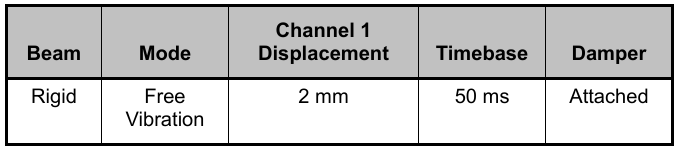

We set up the VDAS settings as teh above.

**Setup – Undamped Condition**

For the undamped case, the apparatus was set in the rigid beam and spring configuration with the dashpot damper attached at 200 mm from the pivot, but providing negligible resistance to motion. The beam was allowed to oscillate freely after an initial disturbance. Displacement and acceleration sensors were used to record the vibration response.

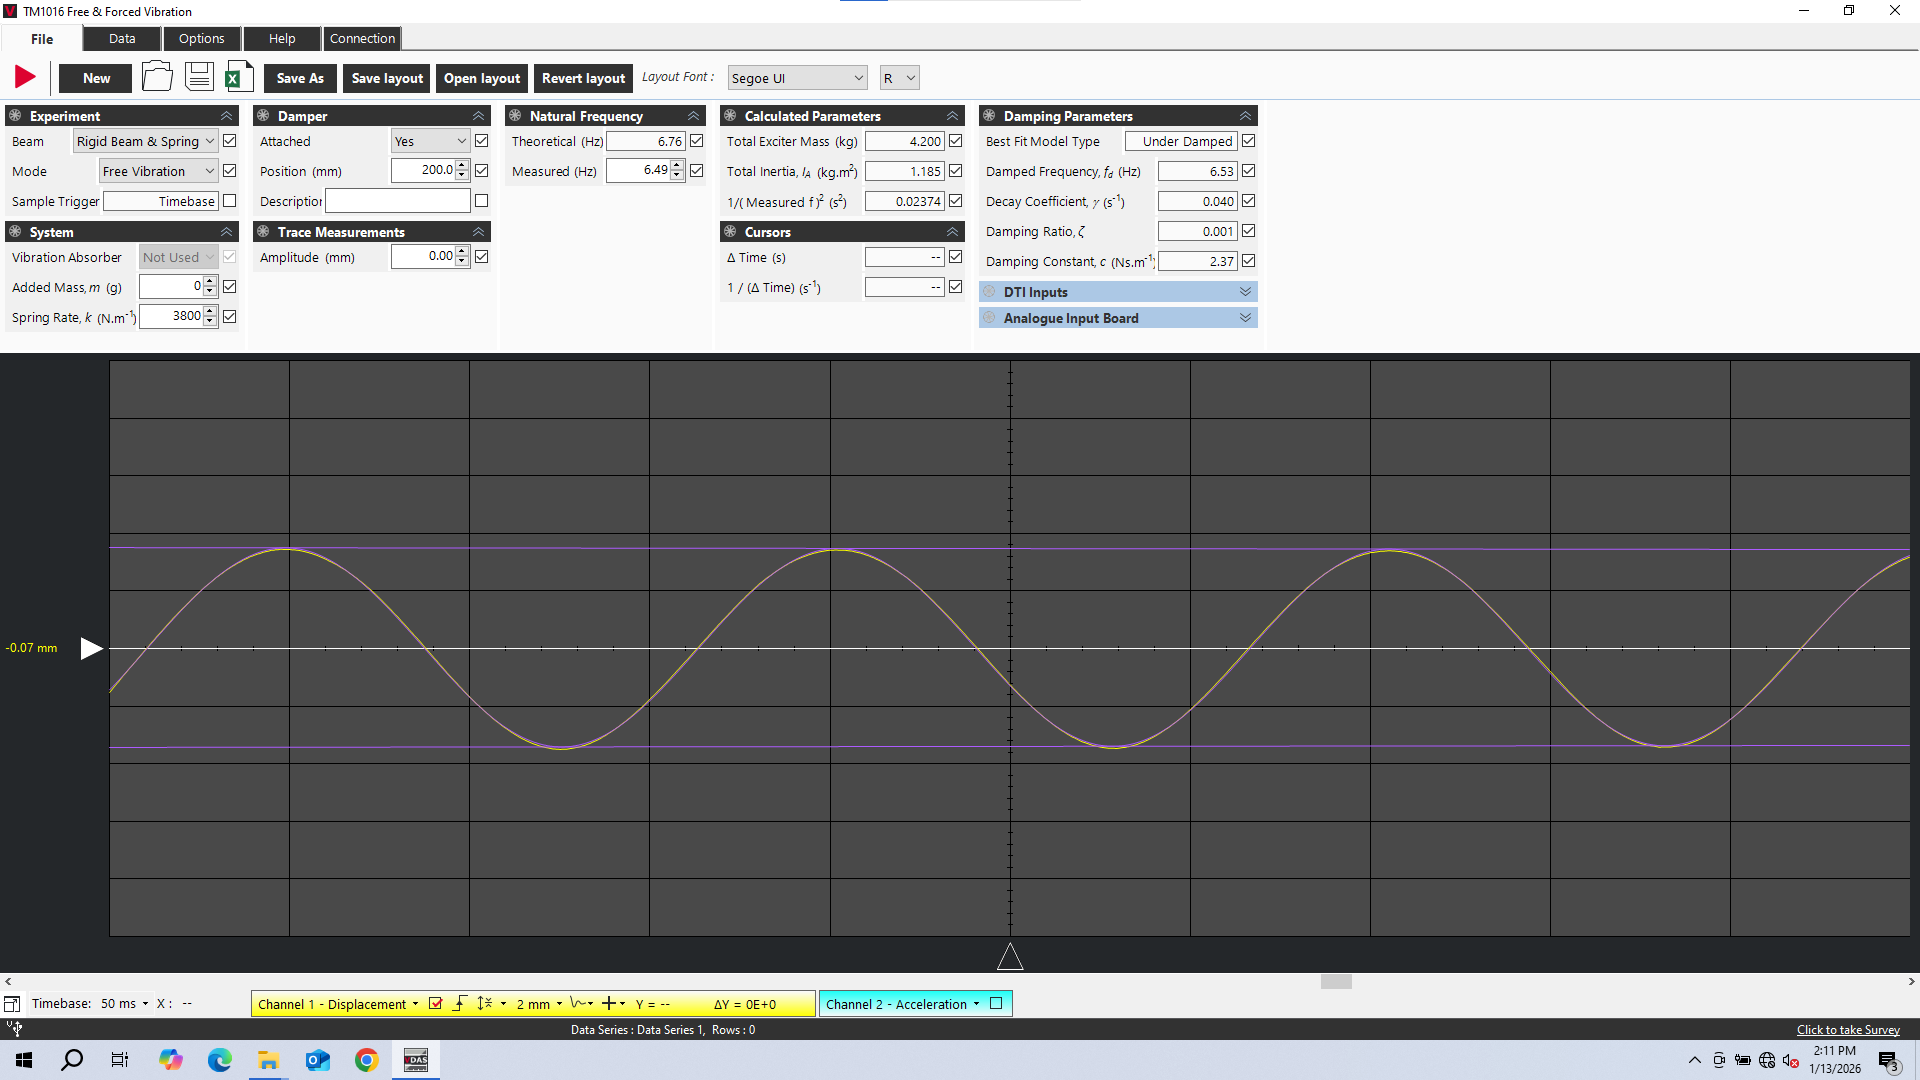


In the undamped condition, the dashpot damper is attached but offers negligible resistance to motion. The displacement waveform shows a nearly constant amplitude with very slow decay, indicating minimal energy loss. The measured natural frequency is approximately 6.49 Hz, and the damping ratio is very small (
𝜁
≈
0.001
ζ≈0.001), confirming that the system behaves almost like an ideal undamped oscillator.

**Setup – Fully Open Damper**

For the fully open damper condition, the experimental setup remained the same, with the dashpot damper positioned 200 mm from the pivot. The damper valve was fully opened to introduce light viscous damping into the system. The beam was then excited and its vibration response was measured using the installed sensors.

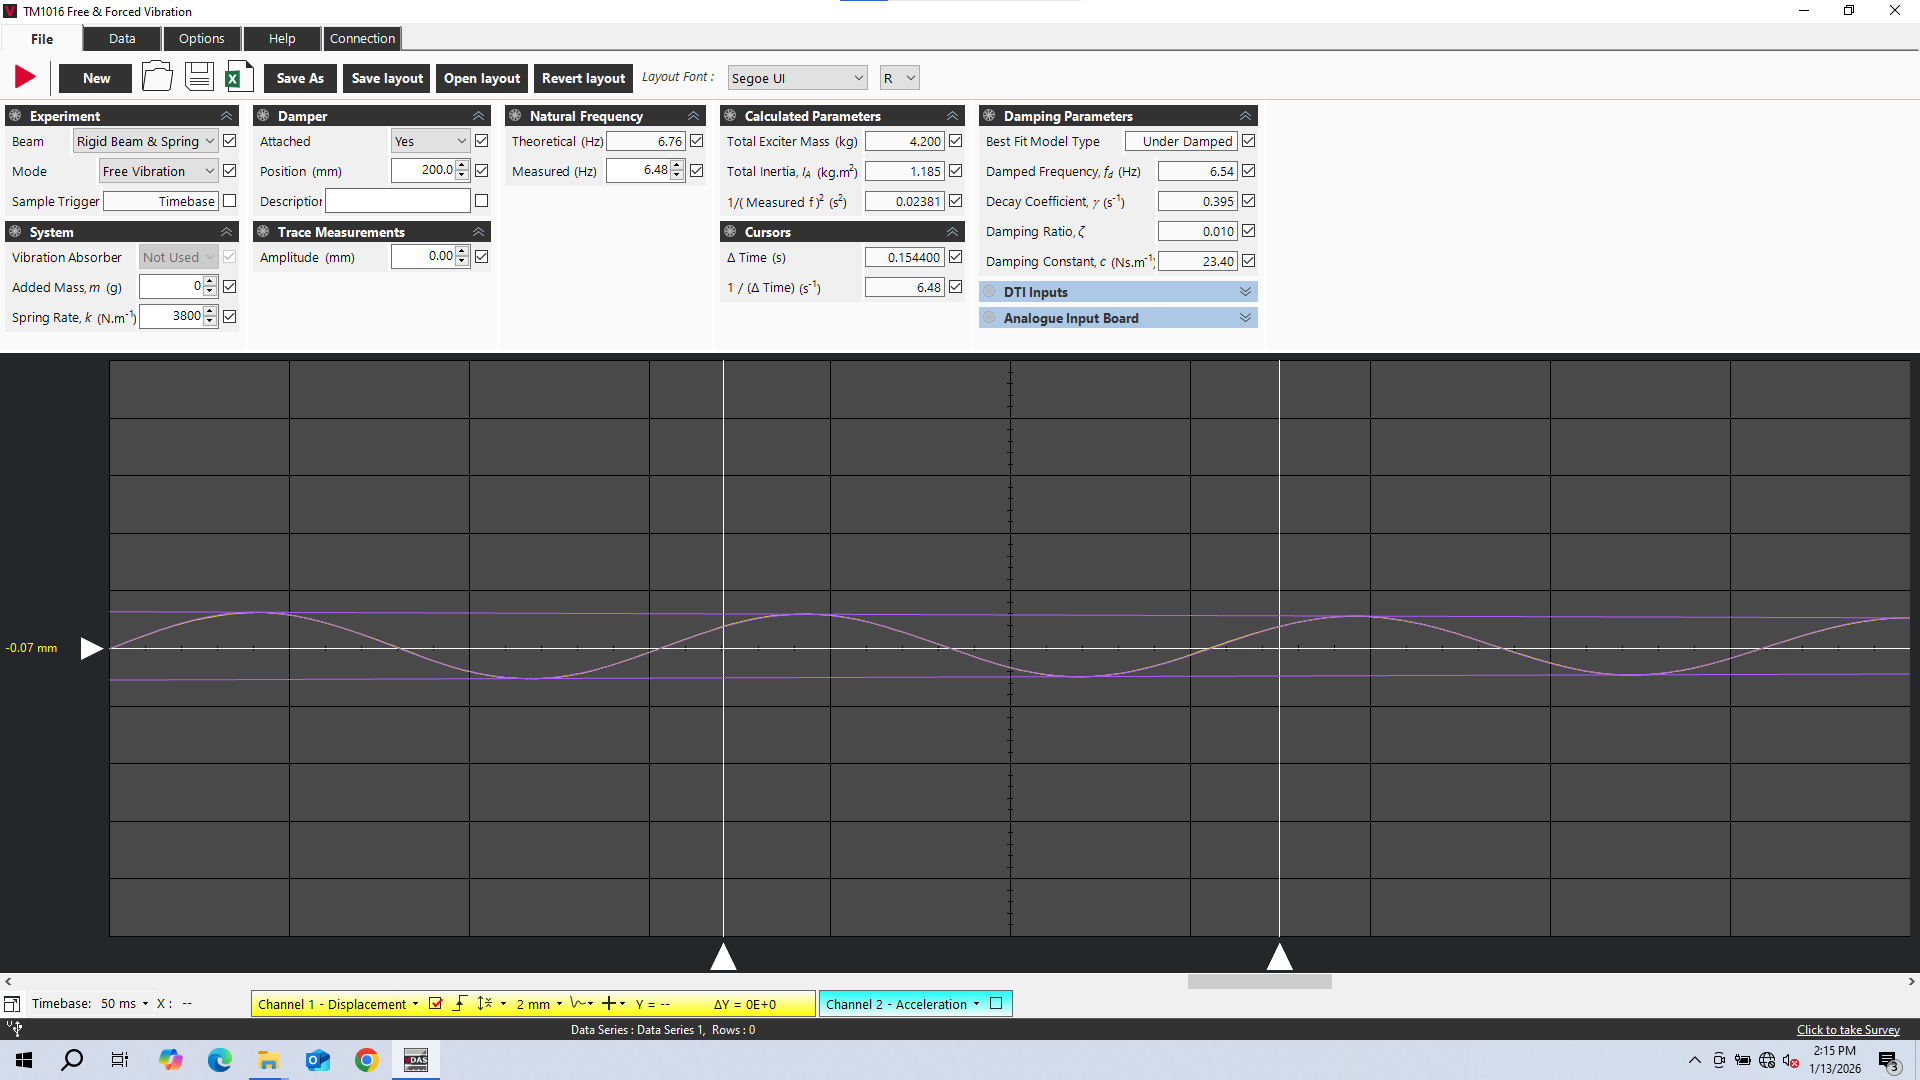

When the damper is fully open, a small amount of viscous damping is introduced into the system. The vibration amplitude decreases slightly compared to the undamped case. The natural frequency remains nearly unchanged at 6.48 Hz, while the damping ratio increases to about
𝜁
≈
0.01
ζ≈0.01. This shows that light damping affects amplitude decay but does not significantly alter the natural frequency.

**Setup – Half Open Damper**

In the half open damper condition, the rigid beam and spring setup was retained, and the dashpot damper was kept at 200 mm from the pivot. The damper opening was adjusted to the half open position to provide a moderate level of damping. The beam response was recorded under this condition.

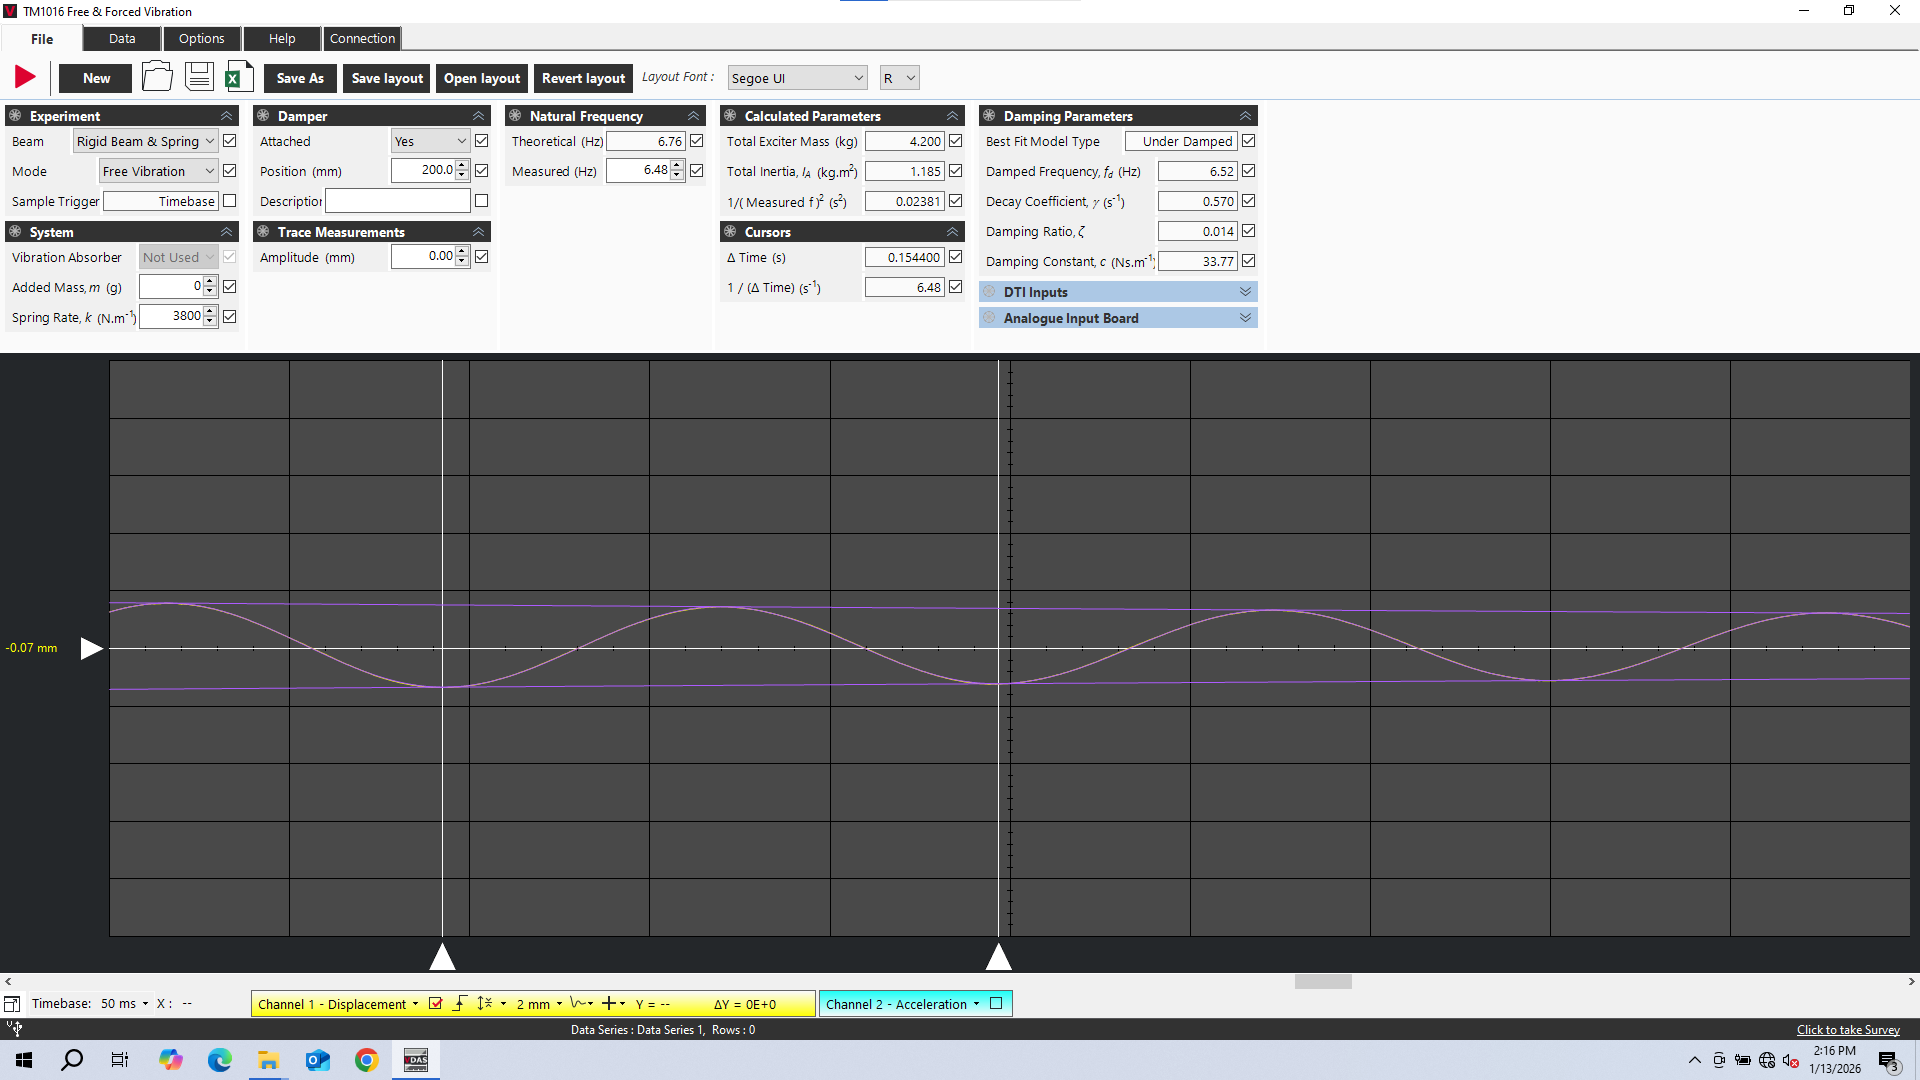

With the damper half open, the resistance to motion increases further. The displacement waveform shows a faster decay in amplitude, indicating higher energy dissipation. The measured natural frequency remains close to 6.48 Hz, while the damping ratio increases to approximately
𝜁
≈
0.014
ζ≈0.014. This confirms that increasing damping accelerates the reduction in vibration amplitude.

**Setup – Fully Shut Damper**

For the fully shut damper condition, the same rigid beam and spring arrangement was used with the dashpot damper fixed at 200 mm from the pivot. The damper valve was completely shut to apply maximum damping. The resulting vibration response of the beam was measured for analysis.

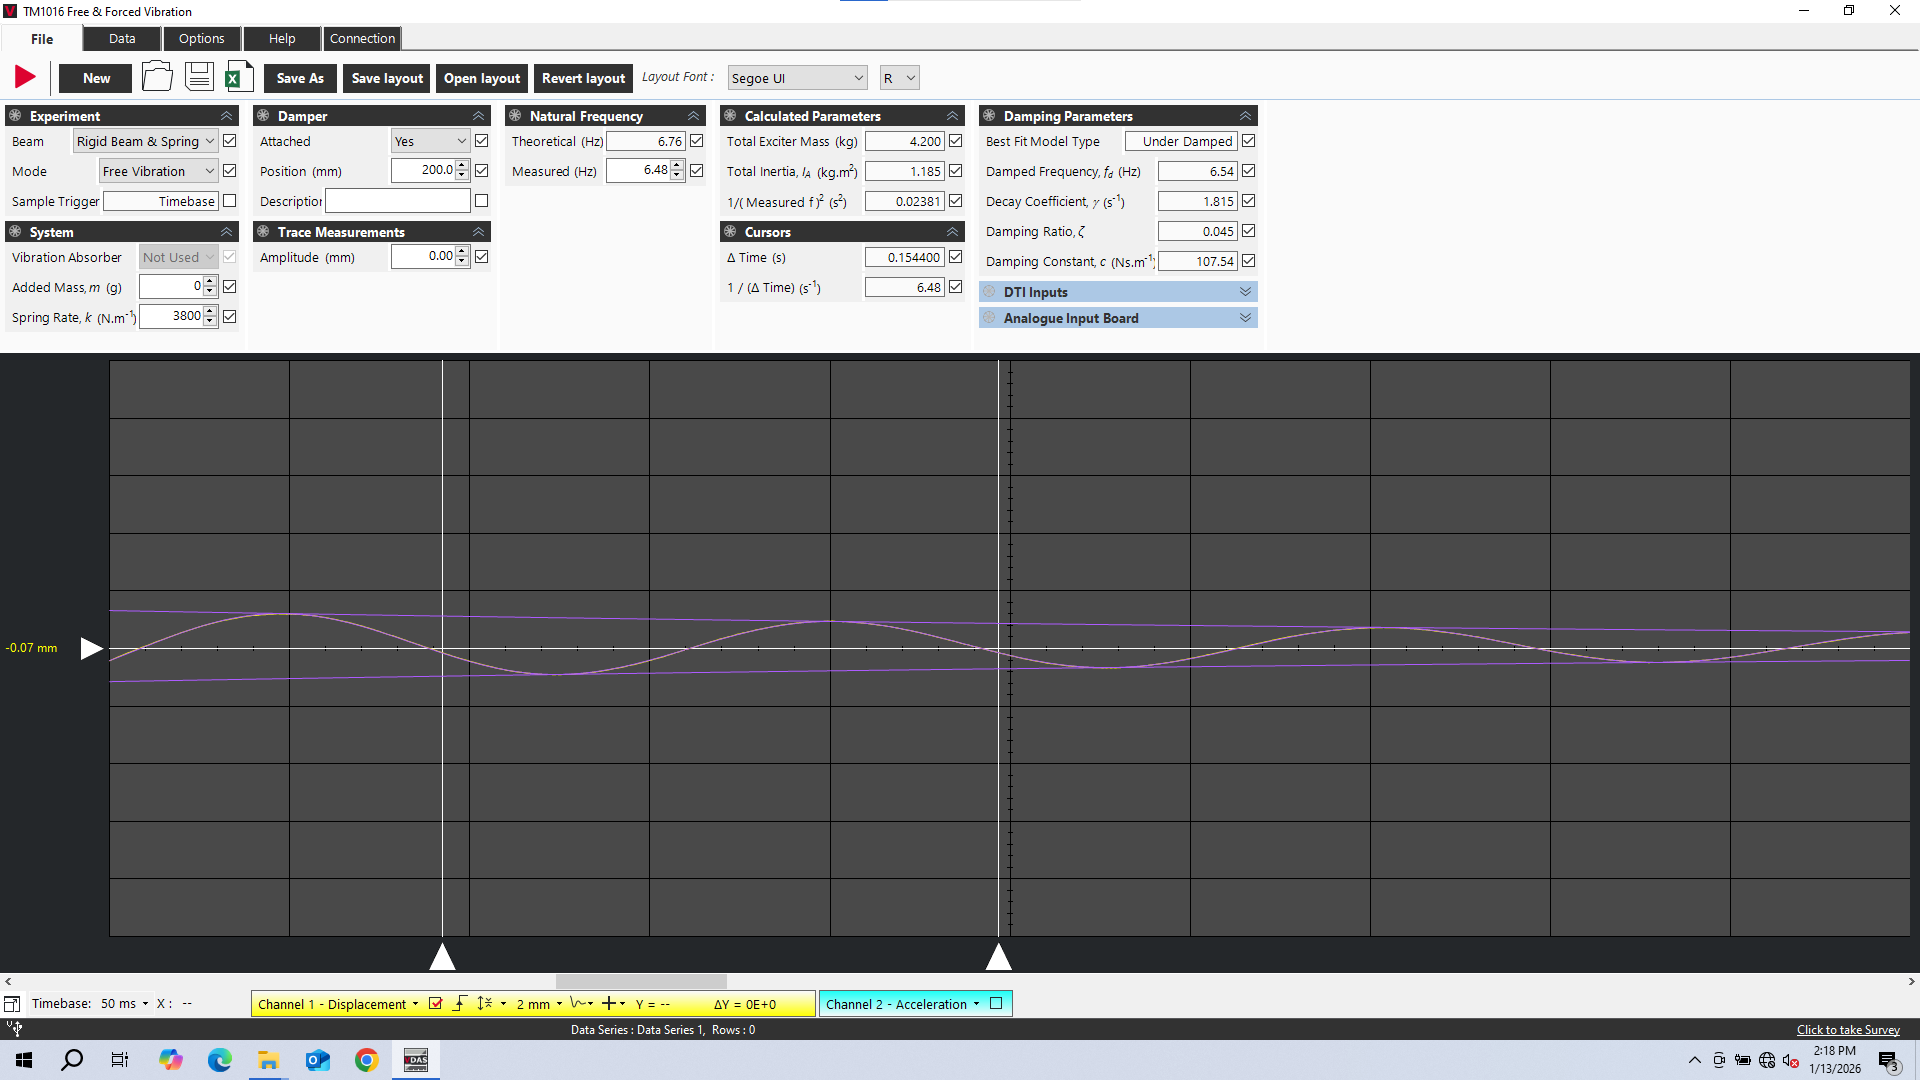

---


In the fully shut condition, maximum damping is applied to the system. The oscillations decay rapidly, and the vibration amplitude is significantly reduced. The natural frequency remains approximately 6.48 Hz, while the damping ratio reaches its highest value of
𝜁
≈
0.045
ζ≈0.045. This indicates a strongly damped but still underdamped system, where vibrations die out quickly.



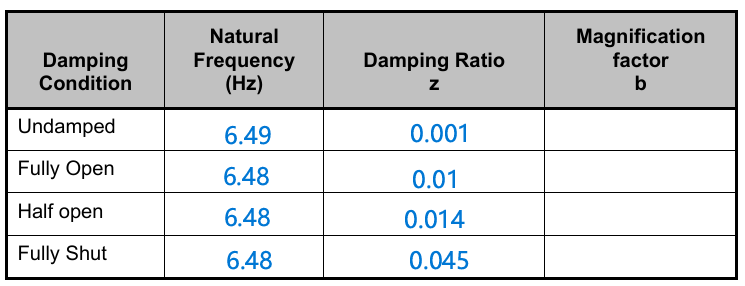

